In [1]:
# Install Libraries
!pip install matplotlib numpy

In [3]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import json

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [4]:
# Create Flight Grid
grid = np.zeros((20,20), dtype=int)

print(grid)


[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


In [5]:
# Define Drone Start Position
drone = (2,2)

grid[drone] = 2

print("Drone Start:", drone)

Drone Start: (2, 2)


In [6]:
# Add Waypoints
waypoints = [

    (5,5),

    (10,8),

    (14,15),

    (18,18)

]

for wp in waypoints:

    grid[wp] = 3

In [7]:
# Add No-Fly Zones
obstacles = [

    (6,6),(6,7),(6,8),

    (9,10),(10,10),(11,10),

    (15,12),(15,13),(15,14),

    (12,5),(13,5),(14,5)

]

for obs in obstacles:

    grid[obs] = 1

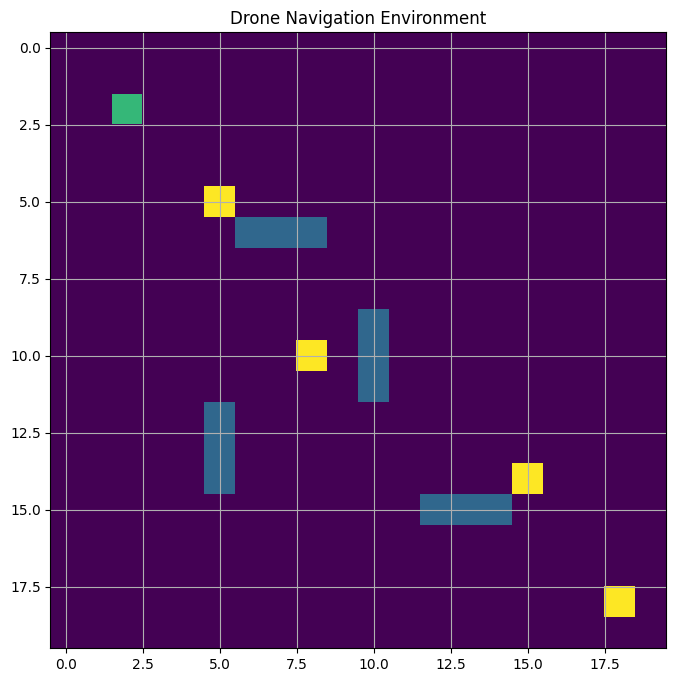

In [8]:
# Visualize Environment
plt.figure(figsize=(8,8))

plt.imshow(grid, cmap="viridis")

plt.title("Drone Navigation Environment")

plt.grid(True)

plt.show()

In [9]:
# Create Flight Path
flight_path = [

    drone,

    (3,3),

    (4,4),

    (5,5),

    (7,6),

    (9,7),

    (10,8),

    (12,10),

    (14,15),

    (16,16),

    (18,18)

]

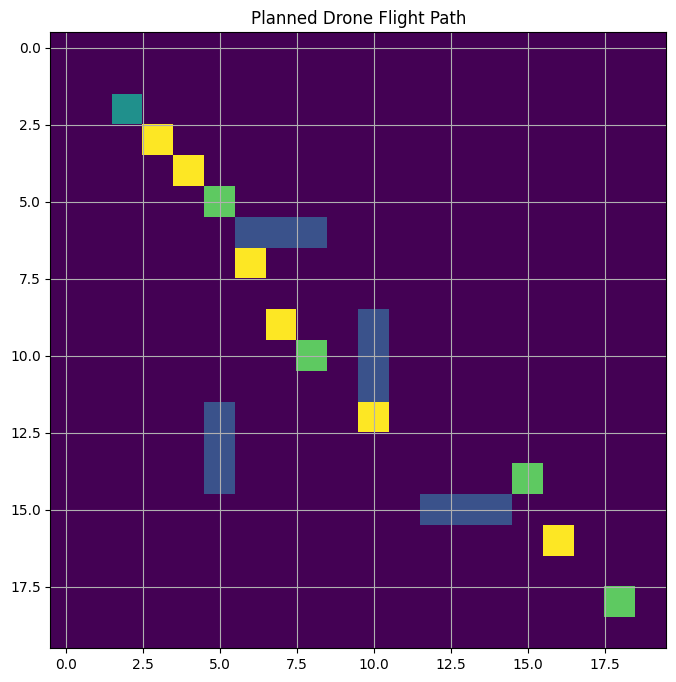

In [10]:
# Draw Flight Path
path_grid = grid.copy()

for point in flight_path:

    if path_grid[point] == 0:

        path_grid[point] = 4

path_grid[drone] = 2

plt.figure(figsize=(8,8))

plt.imshow(path_grid, cmap="viridis")

plt.title("Planned Drone Flight Path")

plt.grid(True)

plt.show()

In [11]:
# Animated Drone Flight
# Import Libraries

from IPython.display import clear_output
import time

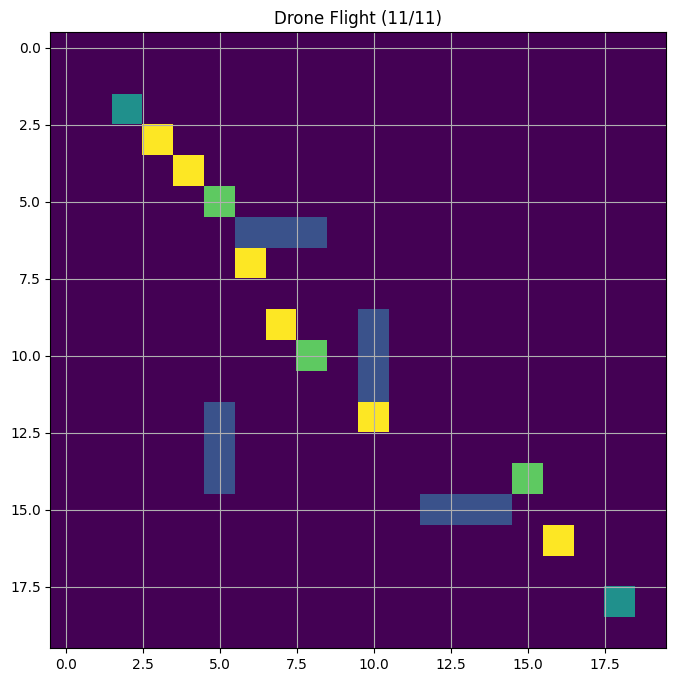

✅ Mission Completed


In [12]:
animation_grid = grid.copy()

for step, position in enumerate(flight_path):

    clear_output(wait=True)

    display_grid = animation_grid.copy()

    # Draw visited path
    for visited in flight_path[:step]:

        if display_grid[visited] == 0:

            display_grid[visited] = 4

    # Drone current position
    display_grid[position] = 2

    plt.figure(figsize=(8,8))

    plt.imshow(display_grid, cmap="viridis")

    plt.title(f"Drone Flight ({step+1}/{len(flight_path)})")

    plt.grid(True)

    plt.show()

    time.sleep(0.4)

print("✅ Mission Completed")

In [13]:
# Professional Custom Colors
from matplotlib.colors import ListedColormap, BoundaryNorm

colors = [

    "white",       # Empty

    "black",       # No-Fly Zone

    "dodgerblue",  # Drone

    "limegreen",   # Waypoints

    "gold"         # Flight Path

]

cmap = ListedColormap(colors)

bounds = [-0.5,0.5,1.5,2.5,3.5,4.5]

norm = BoundaryNorm(bounds,cmap.N)

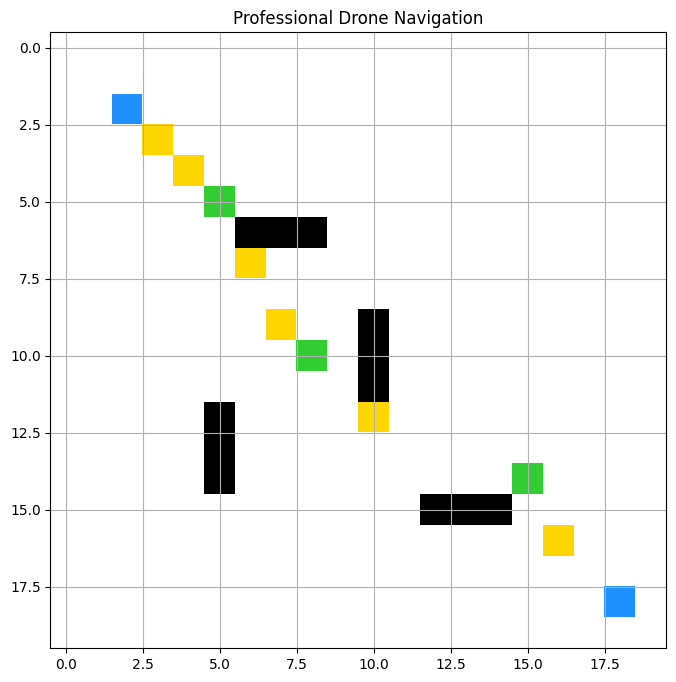

In [14]:
plt.figure(figsize=(8,8))

plt.imshow(display_grid,cmap=cmap,norm=norm)

plt.title("Professional Drone Navigation")

plt.grid(True)

plt.show()

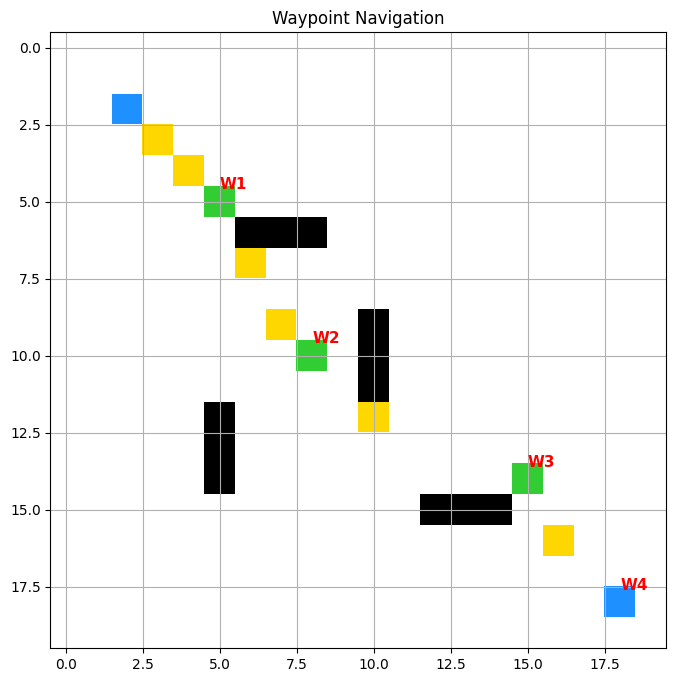

In [15]:
# Waypoint Labels
plt.figure(figsize=(8,8))

plt.imshow(display_grid,cmap=cmap,norm=norm)

for i, wp in enumerate(waypoints):

    plt.text(wp[1], wp[0]-0.4,
             f"W{i+1}",
             color="red",
             fontsize=11,
             weight="bold")

plt.title("Waypoint Navigation")

plt.grid(True)

plt.show()

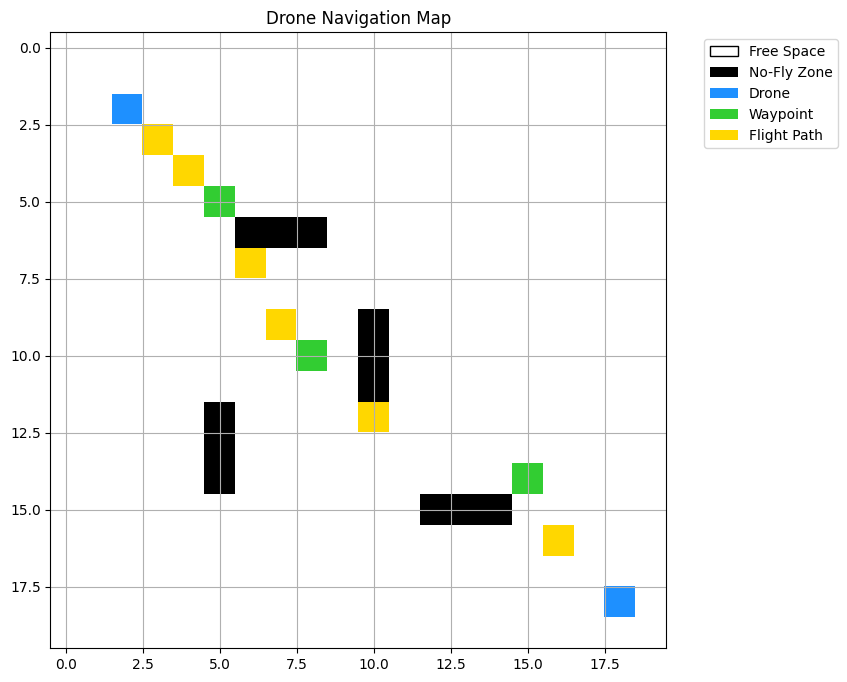

In [16]:
# Professional Legend
from matplotlib.patches import Patch

legend_elements = [

    Patch(facecolor="white",edgecolor="black",label="Free Space"),

    Patch(facecolor="black",label="No-Fly Zone"),

    Patch(facecolor="dodgerblue",label="Drone"),

    Patch(facecolor="limegreen",label="Waypoint"),

    Patch(facecolor="gold",label="Flight Path")

]

plt.figure(figsize=(8,8))

plt.imshow(display_grid,cmap=cmap,norm=norm)

plt.legend(handles=legend_elements,
           bbox_to_anchor=(1.05,1),
           loc="upper left")

plt.title("Drone Navigation Map")

plt.grid(True)

plt.show()

In [17]:
# Mission Statistics
distance = len(flight_path)-1

visited = len(waypoints)

print("="*45)
print("DRONE MISSION REPORT")
print("="*45)

print(f"Mission Status     : SUCCESS")

print(f"Waypoints Visited  : {visited}")

print(f"Flight Distance    : {distance} Units")

print(f"No-Fly Zones       : {len(obstacles)}")

print(f"Drone ID           : Drone-01")

print("="*45)

DRONE MISSION REPORT
Mission Status     : SUCCESS
Waypoints Visited  : 4
Flight Distance    : 10 Units
No-Fly Zones       : 12
Drone ID           : Drone-01


In [18]:
# Export JSON
mission = {

    "drone":"Drone-01",

    "waypoints":visited,

    "distance":distance,

    "obstacles":len(obstacles),

    "status":"Mission Complete"

}

with open("drone_mission.json","w") as file:

    json.dump(mission,file,indent=4)

print("✅ Mission Saved")

✅ Mission Saved


In [19]:
# Download Outputs
plt.imsave("flight_path.png",display_grid,cmap=cmap)

from google.colab import files

files.download("flight_path.png")

files.download("drone_mission.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>